In [5]:
import joblib
import numpy as np
import librosa
import os
from utils.carregar_audio import carregar_audio
from utils.extrair_atributos import extract_feature

In [13]:
LABELS = {0: 'vio', 1: 'pia', 2: 'cla'}

In [23]:
# 1. carrega o modelo e o scaler salvos
model  = joblib.load("svm_instrumentos.pkl")
scaler = joblib.load("scaler_instrumentos.pkl")


In [33]:
path = "datasets/new_audio/vio_seg002.wav"

y, _ = librosa.load("datasets/new_audio/vio_seg002.wav")
features = np.array(extract_feature(y)).reshape(1, -1)
features = scaler.transform(features)
pred = model.predict(features)[0]



Exemplo

In [41]:
print("Intrumento Real: ", path.split("/")[2].split("_")[0])

print("Intrumento Predito: ", LABELS[pred])

Intrumento Real:  vio
Intrumento Predito:  vio


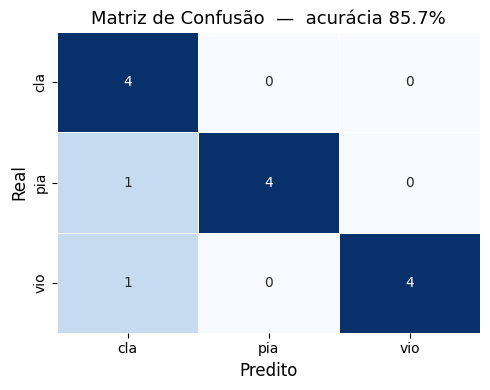

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

datasets  = os.path.join("datasets", "new_audio")
classes   = ["cla", "pia", "vio"]

y_true, y_pred = [], []

for arquivo in sorted(os.listdir(datasets)):
    if not arquivo.endswith(".wav"):
        continue

    verdadeiro = arquivo.split("_")[0]
    caminho    = os.path.join(datasets, arquivo)

    y, sr    = librosa.load(caminho, sr=22050, mono=True)
    features = np.array(extract_feature(y)).reshape(1, -1)
    features = scaler.transform(features)

    pred = model.predict(features)[0]

    y_true.append(verdadeiro)
    y_pred.append(LABELS[pred])

cm = confusion_matrix(y_true, y_pred, labels=classes)
acuracia = cm.diagonal().sum() / cm.sum()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=classes, yticklabels=classes,
    linewidths=0.5, linecolor="white",
    cbar=False, ax=ax,
)
ax.set_xlabel("Predito", fontsize=12)
ax.set_ylabel("Real", fontsize=12)
ax.set_title(f"Matriz de Confusão  —  acurácia {acuracia:.1%}", fontsize=13)
plt.tight_layout()
plt.show()
